In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/ProjetoExtracaoIBMEC'
!mkdir -p "$PROJECT_DIR"
%cd "$PROJECT_DIR"


/content/drive/MyDrive/ProjetoExtracaoIBMEC


In [ ]:
!git clone https://github.com/leonardod7/ProjetoExtracaoIBMEC.git
%cd ProjetoExtracaoIBMEC


Cloning into 'ProjetoExtracaoIBMEC'...
remote: Enumerating objects: 22, done.
remote: Total 22 (delta 0), reused 0 (delta 0), pack-reused 22 (from 1)
Receiving objects: 100% (22/22), 66.82 MiB | 10.38 MiB/s, done.
Updating files: 100% (17/17), done.
/content/drive/MyDrive/ProjetoExtracaoIBMEC/ProjetoExtracaoIBMEC


In [ ]:
!pip install -r requirements.txt


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
%pwd
!ls -la
!pip -q install tree
!tree -L 3


total 75
-rw------- 1 root root 13432 Nov  3 18:07 build_olist_model_fixedpath.py
drwx------ 3 root root  4096 Nov  3 18:07 extracao
-rw------- 1 root root 51813 Nov  3 18:07 extracao_trabalho.ipynb
drwx------ 8 root root  4096 Nov  3 18:07 .git
-rw------- 1 root root  1638 Nov  3 18:07 README.MD
-rw------- 1 root root    23 Nov  3 18:07 teste.py
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.7 MB/s eta 0:00:00
/bin/bash: line 1: tree: command not found


In [ ]:
!ls extracao


base_de_dados


In [ ]:
!head -n 40 build_olist_model_fixedpath.py


#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Build Olist relational model (per Kaggle's "Brazilian E-Commerce by Olist")
and create a denormalized fact table following the provided schema image.

- Reads either CSV or Excel files from DATA_DIR
- Performs the relationships:
    orders <-> order_items (order_id)
    orders <-> order_payments (order_id)
    orders <-> order_reviews (order_id)
    orders <-> customers (customer_id)
    order_items <-> products (product_id)
    order_items <-> sellers (seller_id)
    customers <-> geolocation (zip_code_prefix)
    sellers <-> geolocation (zip_code_prefix)
    products <-> product_category_name_translation (product_category_name)
- Writes outputs to the OUTPUT_DIR as CSV and Parquet (if pyarrow installed)

Author: Generated by ChatGPT
"""

import os
import sys
from typing import Optional, Dict, Any, List
import pandas as pd

# --------------- Configuration ----------------
# Change this to your folder containing the Olist files.
# By d

In [ ]:
import os, re, pathlib

repo_dir = os.getcwd()
data_dir = os.path.join(repo_dir, "extracao", "base_de_dados")
print("Repo:", repo_dir)
print("DATA_DIR novo:", data_dir)
assert os.path.isdir(data_dir), "Pasta extracao/base_de_dados não encontrada!"


Repo: /content/drive/MyDrive/ProjetoExtracaoIBMEC/ProjetoExtracaoIBMEC
DATA_DIR novo: /content/drive/MyDrive/ProjetoExtracaoIBMEC/ProjetoExtracaoIBMEC/extracao/base_de_dados


In [ ]:
py = "build_olist_model_fixedpath.py"
text = open(py, "r", encoding="utf-8").read()


text = re.sub(
    r'DATA_DIR\s*=\s*".*?"',
    f'DATA_DIR = r"{data_dir}"',
    text,
    count=1
)

open(py, "w", encoding="utf-8").write(text)
print("Arquivo atualizado com novo DATA_DIR.")


Arquivo atualizado com novo DATA_DIR.


In [ ]:
!pip -q install pandas numpy pyarrow tqdm python-dotenv scikit-learn matplotlib seaborn



In [ ]:
!python build_olist_model_fixedpath.py


[INFO] Reading input files from: /content/drive/MyDrive/ProjetoExtracaoIBMEC/ProjetoExtracaoIBMEC/extracao/base_de_dados
[OK] Loaded orders               -> (99441, 8) from olist_orders_dataset.csv
[OK] Loaded order_items          -> (112650, 7) from olist_order_items_dataset.csv
[OK] Loaded order_payments       -> (103886, 5) from olist_order_payments_dataset.csv
[OK] Loaded order_reviews        -> (99224, 7) from olist_order_reviews_dataset.csv
[OK] Loaded customers            -> (99441, 5) from olist_customers_dataset.csv
[OK] Loaded products             -> (32951, 9) from olist_products_dataset.csv
[OK] Loaded sellers              -> (3095, 4) from olist_sellers_dataset.csv
[OK] Loaded geolocation          -> (1000163, 5) from olist_geolocation_dataset.csv
[OK] Loaded category_translation -> (71, 2) from product_category_name_translation.csv
[OK] Denormalized order lines shape: (112650, 42)
[OK] Files written:
  - fact_csv: /content/drive/MyDrive/ProjetoExtracaoIBMEC/ProjetoExtraca

In [ ]:
import pandas as pd, os

out = os.path.join("extracao", "base_de_dados", "outputs")
print("Arquivos gerados:", os.listdir(out))

df = pd.read_csv(os.path.join(out, "olist_order_lines_denorm.csv"))
df.head()


Arquivos gerados: ['dim_customers.csv', 'dim_products.csv', 'dim_sellers.csv', 'olist_order_lines_denorm.csv', 'olist_order_lines_denorm.parquet']


,order_id,order_item_id,product_id,seller_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,n_payments,review_score_mean,n_reviews,product_name_lenght,product_description_lenght,product_photos_qty,customer_unique_id,review_score_median,customer_zip_points,seller_zip_points
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,...,1.0,5.0,1.0,58.0,598.0,4.0,871766c5855e863f6eccc05f988b23cb,5.0,149.0,59.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,...,1.0,4.0,1.0,56.0,239.0,2.0,eb28e67c4c0b83846050ddfb8a35d051,4.0,367.0,39.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,...,1.0,5.0,1.0,59.0,695.0,2.0,3818d81c6709e39d06b2738a8d3a2474,5.0,224.0,71.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,...,1.0,4.0,1.0,42.0,480.0,1.0,af861d436cfc08b2c2ddefd0ba074622,4.0,27.0,438.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,...,1.0,5.0,1.0,59.0,409.0,1.0,64b576fb70d441e8f1b2d7d446e483c5,5.0,4.0,119.0


['customer_city', 'customer_id', 'customer_lat', 'customer_lng', 'customer_state', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_zip_points', 'freight_value', 'item_gmv', 'n_payments', 'n_reviews', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_id', 'order_item_id', 'order_purchase_timestamp', 'order_status', 'price', 'product_category_name', 'product_category_name_english', 'product_description_lenght', 'product_height_cm', 'product_id', 'product_length_cm', 'product_name_lenght', 'product_photos_qty', 'product_weight_g', 'product_width_cm', 'review_score_mean', 'review_score_median', 'seller_city', 'seller_id', 'seller_lat', 'seller_lng', 'seller_state', 'seller_zip_code_prefix', 'seller_zip_points', 'shipping_limit_date', 'total_payment_value']
payment_type -> None
price/value  -> price
customer_state -> customer_state
⚠️ Não encontrei colunas para payment_type e/ou price/value.


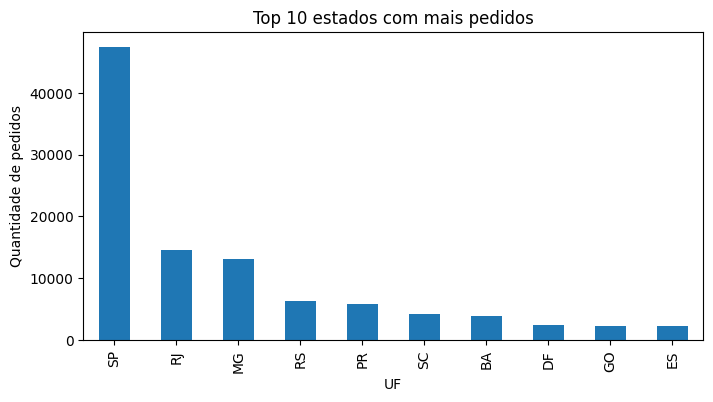

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


print(sorted(df.columns.tolist()))


def pick(cands):
    for c in cands:
        if c in df.columns:
            return c
    return None


COL_PAYMENT_TYPE = pick([
    'payment_type', 'order_payment_type', 'payment_payment_type',
    'payment_type_x', 'payment_type_y'
])
COL_PRICE = pick([

    'payment_value', 'order_payment_value',

    'price', 'order_item_price'
])
COL_CUSTOMER_STATE = pick([
    'customer_state', 'customer_state_x', 'customer_state_y',
    'geolocation_state', 'customer_state_code'
])

print("payment_type ->", COL_PAYMENT_TYPE)
print("price/value  ->", COL_PRICE)
print("customer_state ->", COL_CUSTOMER_STATE)


if COL_PAYMENT_TYPE and COL_PRICE:
    (df
     .dropna(subset=[COL_PAYMENT_TYPE, COL_PRICE])
     .groupby(COL_PAYMENT_TYPE)[COL_PRICE]
     .mean()
     .sort_values()
     .plot(kind='bar', figsize=(8,4)))
    plt.title('Ticket médio por tipo de pagamento')
    plt.ylabel('Valor médio')
    plt.xlabel('Tipo de pagamento')
    plt.show()
else:
    print("⚠️ Não encontrei colunas para payment_type e/ou price/value.")


if COL_CUSTOMER_STATE:
    (df[COL_CUSTOMER_STATE]
     .dropna()
     .value_counts()
     .head(10)
     .plot(kind='bar', figsize=(8,4)))
    plt.title('Top 10 estados com mais pedidos')
    plt.xlabel('UF')
    plt.ylabel('Quantidade de pedidos')
    plt.show()
else:
    print("⚠️ Não encontrei coluna de estado do cliente.")


Colunas do df: ['customer_city', 'customer_id', 'customer_lat', 'customer_lng', 'customer_state', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_zip_points', 'delay_days', 'freight_value', 'item_gmv', 'n_payments', 'n_reviews', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_id', 'order_item_id', 'order_purchase_timestamp', 'order_status', 'price', 'product_category_name', 'product_category_name_english', 'product_description_lenght', 'product_height_cm', 'product_id', 'product_length_cm', 'product_name_lenght', 'product_photos_qty', 'product_weight_g', 'product_width_cm', 'review_score', 'review_score_mean', 'review_score_median', 'seller_city', 'seller_id', 'seller_lat', 'seller_lng', 'seller_state', 'seller_zip_code_prefix', 'seller_zip_points', 'shipping_limit_date', 'total_item', 'total_payment_value'] ...
DELIVERED -> order_delivered_customer_date
ESTIMATED -> order_estimated_delivery_date


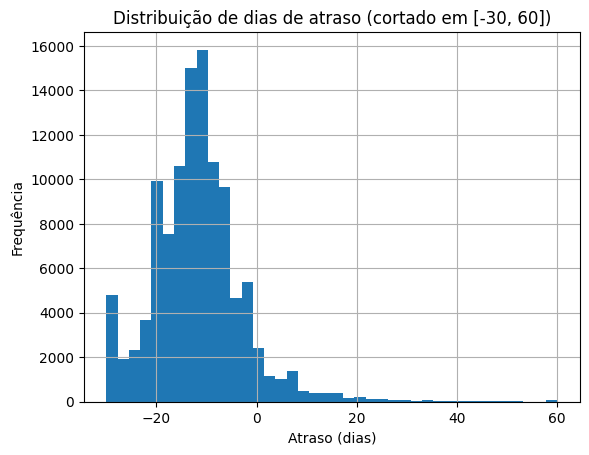

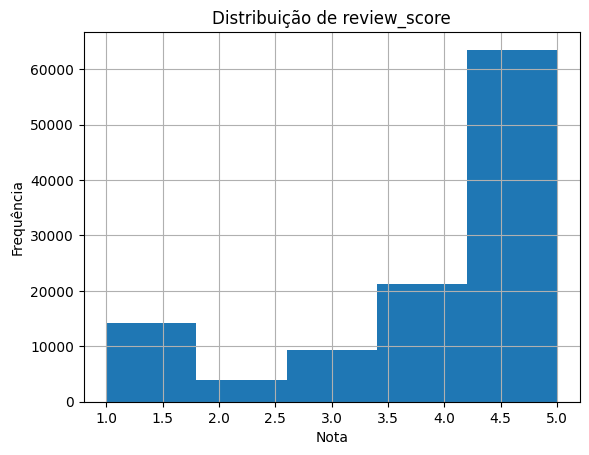

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Colunas do df:", sorted(df.columns.tolist())[:50], "...")


def pick(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None


COL_DELIVERED = pick(['order_delivered_customer_date', 'delivered_date'])
COL_ESTIMATED = pick(['order_estimated_delivery_date', 'estimated_delivery_date'])
COL_REVIEW   = pick(['review_score', 'order_review_score', 'review_score_x', 'review_score_y'])
COL_PRICE    = pick(['price', 'order_item_price'])
COL_FREIGHT  = pick(['freight_value', 'order_item_freight_value'])
print("DELIVERED ->", COL_DELIVERED)
print("ESTIMATED ->", COL_ESTIMATED)
print("REVIEW    ->", COL_REVIEW)
print("PRICE     ->", COL_PRICE)
print("FREIGHT   ->", COL_FREIGHT)

if COL_REVIEW is None and 'order_id' in df.columns:
    base_dir = os.path.join('extracao', 'base_de_dados')
    reviews_path = os.path.join(base_dir, 'olist_order_reviews_dataset.csv')
    if os.path.exists(reviews_path):
        reviews = pd.read_csv(reviews_path, usecols=['order_id','review_score'])
        df = df.merge(reviews, on='order_id', how='left')
        COL_REVIEW = 'review_score'
        print("review_score adicionado via merge com o CSV original.")


if 'delay_days' not in df.columns:
    if COL_DELIVERED and COL_ESTIMATED:
        df[COL_DELIVERED] = pd.to_datetime(df[COL_DELIVERED], errors='coerce')
        df[COL_ESTIMATED] = pd.to_datetime(df[COL_ESTIMATED], errors='coerce')
        df['delay_days'] = (df[COL_DELIVERED] - df[COL_ESTIMATED]).dt.days
        print("delay_days criado a partir de", COL_DELIVERED, "e", COL_ESTIMATED)
    else:
        print("⚠️ Não achei colunas de data para calcular delay_days.")


if COL_PRICE and COL_FREIGHT and 'total_item' not in df.columns:
    df['total_item'] = df[COL_PRICE].fillna(0) + df[COL_FREIGHT].fillna(0)

cols_desc = [c for c in ['delay_days', COL_REVIEW, COL_PRICE, COL_FREIGHT, 'total_item'] if c]
print("\nResumo estatístico:\n", df[cols_desc].describe())

if 'delay_days' in df.columns and COL_REVIEW:
    corr = df['delay_days'].corr(df[COL_REVIEW])
    print(f"\nCorrelação (delay_days × {COL_REVIEW}): {corr:.3f}")


if 'delay_days' in df.columns and COL_REVIEW:
    delayed = df['delay_days'] > 0
    print("\nMédias de review por atraso:")
    print(df.groupby(delayed)[COL_REVIEW].mean().rename(index={False:'pontual/adiantado', True:'atrasado'}))

if 'delay_days' in df.columns:
    df['delay_days'].dropna().clip(-30, 60).hist(bins=40)
    plt.title('Distribuição de dias de atraso (cortado em [-30, 60])')
    plt.xlabel('Atraso (dias)')
    plt.ylabel('Frequência')
    plt.show()

if COL_REVIEW:
    df[COL_REVIEW].dropna().hist(bins=5)
    plt.title('Distribuição de review_score')
    plt.xlabel('Nota')
    plt.ylabel('Frequência')
    plt.show()


In [ ]:
import os, pandas as pd, numpy as np

OUT_BASE = os.path.join('extracao','base_de_dados','outputs')
FIGS = os.path.join(OUT_BASE,'figs'); os.makedirs(FIGS, exist_ok=True)
TABS = os.path.join(OUT_BASE,'tabelas'); os.makedirs(TABS, exist_ok=True)

df['delayed'] = df['delay_days'] > 0

kpis = {}
kpis['n_linhas']      = int(len(df))
kpis['n_delay_valid'] = int(df['delay_days'].notna().sum())
kpis['pct_atraso']    = float((df['delayed'].mean())*100)
kpis['delay_mean']    = float(df['delay_days'].mean())
kpis['delay_median']  = float(df['delay_days'].median())
kpis['score_mean']    = float(df['review_score'].mean())
kpis['score_pontual'] = float(df.loc[~df['delayed'],'review_score'].mean())
kpis['score_atraso']  = float(df.loc[df['delayed'],'review_score'].mean())
kpis['corr_delay_score'] = float(df['delay_days'].corr(df['review_score']))

pd.Series(kpis).to_csv(os.path.join(TABS,'kpis.csv'))
kpis


{'n_linhas': 113314,
 'n_delay_valid': 110839,
 'pct_atraso': 6.436980426072683,
 'delay_mean': -12.035808695495268,
 'delay_median': -13.0,
 'score_mean': 4.032472502046773,
 'score_pontual': 4.1524810230004086,
 'score_atraso': 2.256572472936876,
 'corr_delay_score': -0.22902987885409307}

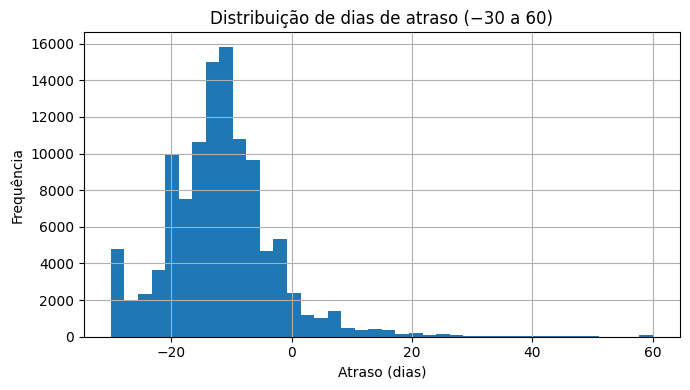

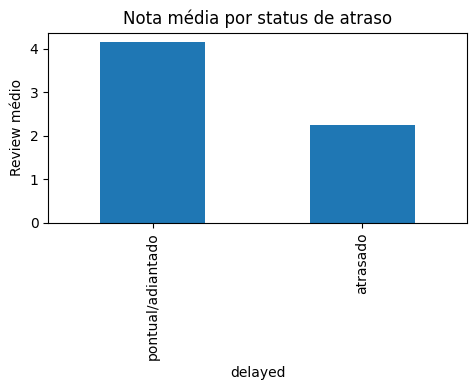

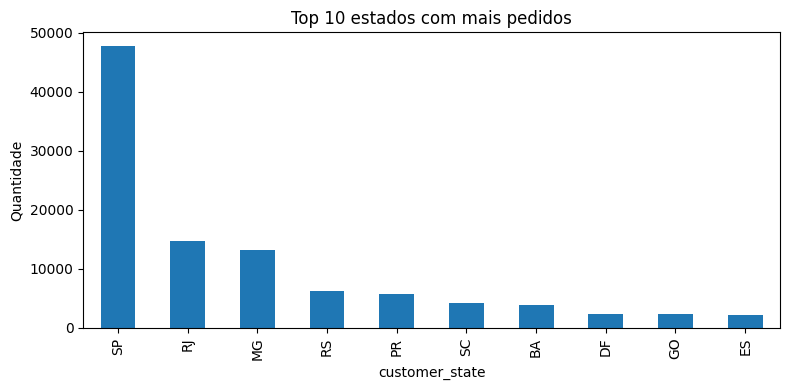

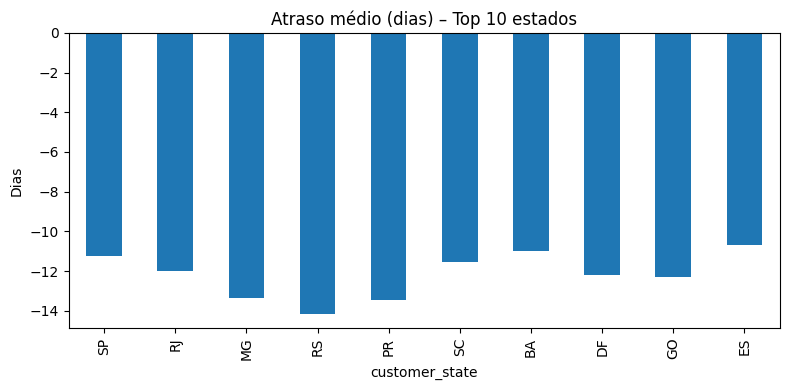

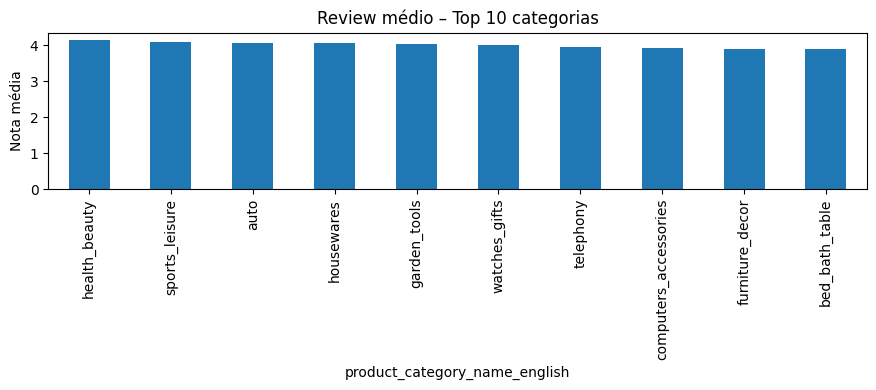

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,4))
df['delay_days'].dropna().clip(-30,60).hist(bins=40)
plt.title('Distribuição de dias de atraso (−30 a 60)')
plt.xlabel('Atraso (dias)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig(os.path.join(FIGS,'dist_delay.png'), dpi=150)
plt.show()


plt.figure(figsize=(5,4))
(df.groupby('delayed')['review_score']
   .mean()
   .rename({False:'pontual/adiantado', True:'atrasado'})
   .plot(kind='bar'))
plt.title('Nota média por status de atraso')
plt.ylabel('Review médio')
plt.tight_layout()
plt.savefig(os.path.join(FIGS,'review_vs_delay_bar.png'), dpi=150)
plt.show()

top_ufs = df['customer_state'].value_counts().head(10).index
aux = (df[df['customer_state'].isin(top_ufs)]
       .groupby('customer_state')
       .agg(qtd=('order_id','count'),
            delay_mean=('delay_days','mean'))
       .sort_values('qtd', ascending=False))
ax = aux['qtd'].plot(kind='bar', figsize=(8,4))
plt.title('Top 10 estados com mais pedidos')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.savefig(os.path.join(FIGS,'top_ufs_qtd.png'), dpi=150)
plt.show()

ax = aux['delay_mean'].plot(kind='bar', figsize=(8,4))
plt.title('Atraso médio (dias) – Top 10 estados')
plt.ylabel('Dias')
plt.tight_layout()
plt.savefig(os.path.join(FIGS,'top_ufs_delay.png'), dpi=150)
plt.show()


top_cats = df['product_category_name_english'].fillna(df['product_category_name']).value_counts().head(10).index
aux2 = (df[df['product_category_name_english'].fillna(df['product_category_name']).isin(top_cats)]
        .groupby(df['product_category_name_english'].fillna(df['product_category_name']))
        ['review_score'].mean().sort_values(ascending=False))
aux2.plot(kind='bar', figsize=(9,4))
plt.title('Review médio – Top 10 categorias')
plt.ylabel('Nota média')
plt.tight_layout()
plt.savefig(os.path.join(FIGS,'top_cats_review.png'), dpi=150)
plt.show()


In [ ]:
desc = df[['delay_days','review_score','price','freight_value','total_item']].describe()
desc.to_csv(os.path.join(TABS,'descritivas.csv'))
desc


,delay_days,review_score,price,freight_value,total_item
count,110839.000000,112372.000000,113314.000000,113314.000000,113314.000000
mean,-12.035809,4.032473,120.478701,19.979428,140.458128
std,10.159965,1.387849,183.279678,15.783227,190.362183
min,-147.000000,1.000000,0.850000,0.000000,6.080000
25%,-17.000000,4.000000,39.900000,13.080000,55.180000
50%,-13.000000,5.000000,74.900000,16.260000,92.205000
75%,-7.000000,5.000000,134.900000,21.150000,157.790000
max,188.000000,5.000000,6735.000000,409.680000,6929.310000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = df[['delay_days']].fillna(0)
y = df['review_score'].fillna(df['review_score'].mean())

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

baseline_mae = mean_absolute_error(yte, [ytr.mean()]*len(yte))

lr = LinearRegression().fit(Xtr, ytr)
pred = lr.predict(Xte)
model_mae = mean_absolute_error(yte, pred)

coef = float(lr.coef_[0]); intercept = float(lr.intercept_)

pd.Series({
    'baseline_mae': baseline_mae,
    'linear_mae': model_mae,
    'linear_coef_delay': coef,
    'linear_intercept': intercept
}).to_csv(os.path.join(TABS,'modelo_regressao.csv'))

baseline_mae, model_mae, coef, intercept


(1.0828251216820528,
 1.05940169543041,
 -0.03453842409643218,
 3.6240833767156895)